In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Rutas
base_path = r"C:\Users\braya\Documents\TFM_UCM_Enagas\tfm_enagas"

#ruta_sensores_clean = os.path.join(base_path, "data", "processed", "df_sensores_ERM_400_2023_2024_limpio.csv")
ruta_sensores_clean = os.path.join(base_path, "data", "processed", "df_sensores_ERM_6500_2022_2023_limpio.csv")

#ruta_sap_clean = os.path.join(base_path, "data", "processed", "df_sap_erm_400_limpio.csv")
ruta_sap_clean = os.path.join(base_path, "data", "processed", "df_sap_erm_6500_limpio.csv")

# 2. Cargar Sensores (Forzamos que 'datetime' vuelva a ser el índice y sea tipo fecha)
df = pd.read_csv(ruta_sensores_clean, parse_dates=['datetime'])
df.set_index('datetime', inplace=True)

# 3. Cargar SAP
df_sap = pd.read_csv(ruta_sap_clean, parse_dates=['datetime_fallo'])

print("Datos cargados y listos para el Análisis")

Datos cargados y listos para el Análisis


In [79]:
df.shape

(105109, 18)

In [80]:
df.head(2)

,presion_in_A,presion_in_B,presion_in_C,temperatura_in_A,temperatura_in_B,temperatura_in_C,caudal_bruto_A,caudal_bruto_B,caudal_bruto_C,caudal_nominal_A,caudal_nominal_B,caudal_nominal_C,caudal_min_diario_A,caudal_min_diario_B,caudal_min_diario_C,caudal_max_diario_A,caudal_max_diario_B,caudal_max_diario_C
datetime,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,17.124897,17.114777,17.114777,5.719018,7.483863,10.334971,1846.089820,1561.679383,0.0,31869.921725,26747.092334,0.0,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38
2022-01-01 00:05:00,17.127205,17.117367,17.118143,5.895065,7.342698,10.532716,1831.851803,1518.767362,0.0,31605.431151,26031.402012,0.0,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38,1.000000e+38


In [81]:
df_sap.head()

,Aviso,DESCRIPCIÓN AVISO,UT,Denominación,Equipo,Denominación.1,GR-SUBGR,TAMAÑO ERM,Aviso externo,Orden,Inicio deseado,Fin deseado,Inicio avería,Ini.avería (h),Fin de avería,Fin de avería.1,Ce.emplazam.,COMENTARIOS AVISOS,datetime_fallo
0,10216955,Regulación. Disparo VIS LA/LB,ERM_6500,Regulación,5.000102e+09,02024 Válvula de seguridad interr VIS1A,2024.0,"G-6500 12""",20210823-026-TM,400001745027,2021-08-23,2021-08-28,NaN,00:00:00,NaN,00:00:00,7416,Notificación de VIS activas en líneas A y B.\n...,2021-08-23
1,10246720,Alarma Vis B- ERM_6500,ERM_6500,Regulación,5.000102e+09,02024 Válvula de seguridad interr VIS1B,2024.0,"G-6500 12""",20230330-082-IN,400002021885,2023-03-30,2023-03-30,NaN,00:00:00,NaN,00:00:00,7416,Avisa CPC indicando que existe señal de dispar...,2023-03-30
2,10240481,Regulación viernes,ERM_6500,Regulación,5.000102e+09,17001 Regulador de gas VCP1B,17001.0,"G-6500 12""",20221125-067-IN,400001964000,2022-11-25,2022-11-30,NaN,00:00:00,NaN,00:00:00,7416,ERM_6500\n20221125067\n22:05 22:50 23:40\n...,2022-11-25
3,10233093,ERM_6500 Fallo funcional Aperflux LA,ERM_6500,Regulación,5.000102e+09,17001 Regulador de gas VCP1A,17001.0,"G-6500 12""",NaN,400001885191,2022-06-20,2022-07-20,NaN,00:00:00,NaN,00:00:00,7416,"Fallo funcional, se detecta rotura de membrana...",2022-06-20
4,10230072,ERM_6500 Fallo regulacion Aperflux Linea B,ERM_6500,Regulación,5.000102e+09,17001 Regulador de gas VCP1B,17001.0,"G-6500 12""",NaN,400001855792,2022-04-27,2023-04-27,NaN,00:00:00,NaN,00:00:00,7416,Fallo regulacion y estanqueidad.,2022-04-27


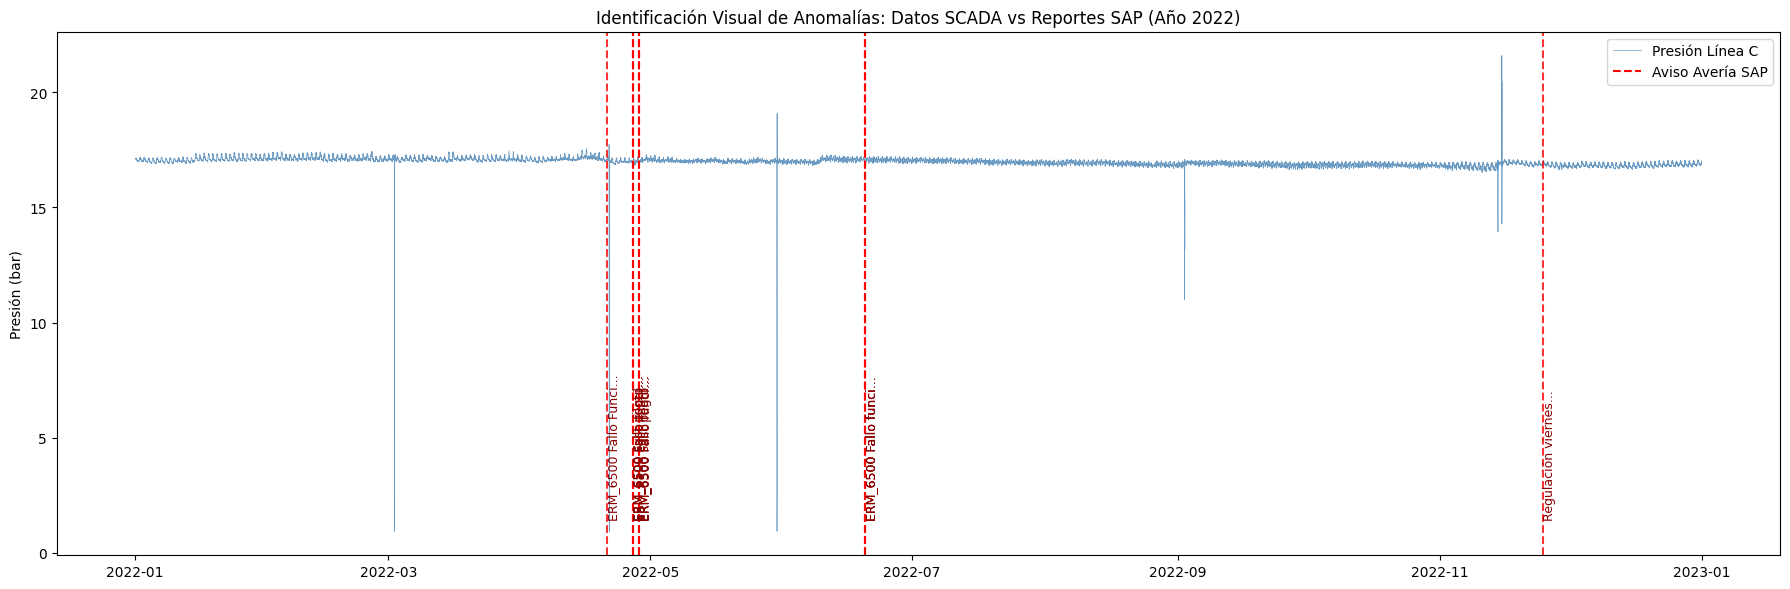

In [83]:
# 1. Filtrar los avisos de SAP para que coincidan con el año de nuestro dataset
df_sap_2022 = df_sap[(df_sap['datetime_fallo'] >= df.index.min()) & (df_sap['datetime_fallo'] <= df.index.max())]

# 2. Gráfico histórico de presión con marcas de mantenimiento
plt.figure(figsize=(18, 6))
plt.plot(df.index, df['presion_in_C'], label='Presión Línea C', color='steelblue', alpha=0.8, linewidth=0.5)

# 3. Dibujar líneas verticales para cada avería de SAP
for idx, row in df_sap_2022.iterrows():
    plt.axvline(x=row['datetime_fallo'], color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    
    # Usamos 'DESCRIPCIÓN AVISO'
    # Convertimos a string por si hay algún valor nulo (NaN)
    texto_aviso = str(row['DESCRIPCIÓN AVISO'])
    
    # Etiqueta con el texto del aviso (recortado a 20 caracteres para que no ocupe mucho)
    plt.text(row['datetime_fallo'], df['presion_in_C'].min() + 0.5, texto_aviso[:20]+'...', 
             rotation=90, color='darkred', fontsize=9, verticalalignment='bottom')

# Añadir una leyenda fantasma para las líneas rojas
plt.plot([], [], color='red', linestyle='--', label='Aviso Avería SAP')

plt.title('Identificación Visual de Anomalías: Datos SCADA vs Reportes SAP (Año 2022)')
plt.ylabel('Presión (bar)')
plt.legend()
plt.tight_layout()
plt.show()

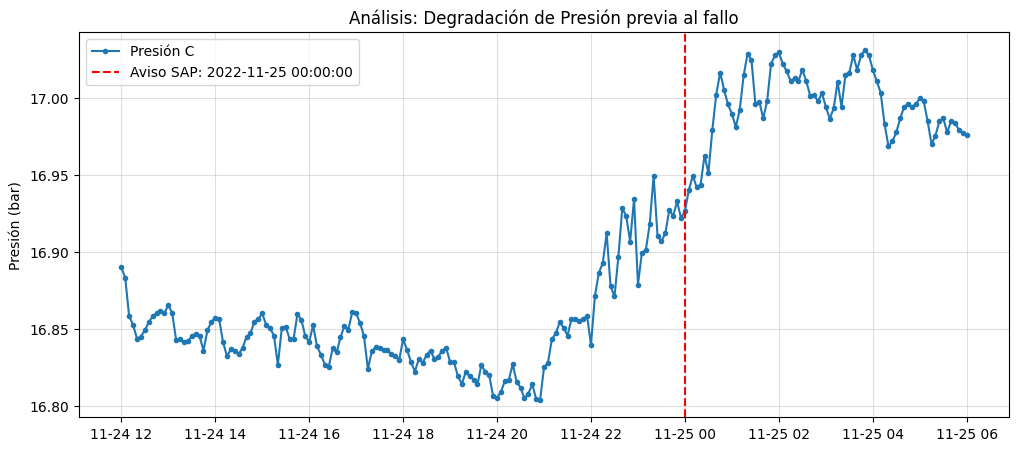

In [84]:
if not df_sap_2022.empty:
    # Tomamos el primer aviso del 2022 (ej. la de febrero)
    fecha_aviso = df_sap_2022['datetime_fallo'].iloc[0]
    
    # Ventana de tiempo: 12 horas antes y 6 horas después
    inicio_ventana = fecha_aviso - pd.Timedelta(hours=12)
    fin_ventana = fecha_aviso + pd.Timedelta(hours=6)
    
    df_zoom = df.loc[inicio_ventana:fin_ventana]
    
    plt.figure(figsize=(12, 5))
    plt.plot(df_zoom.index, df_zoom['presion_in_C'], label='Presión C', marker='.')
    plt.axvline(fecha_aviso, color='red', linestyle='--', label=f'Aviso SAP: {fecha_aviso}')
    
    plt.title('Análisis: Degradación de Presión previa al fallo')
    plt.ylabel('Presión (bar)')
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.show()

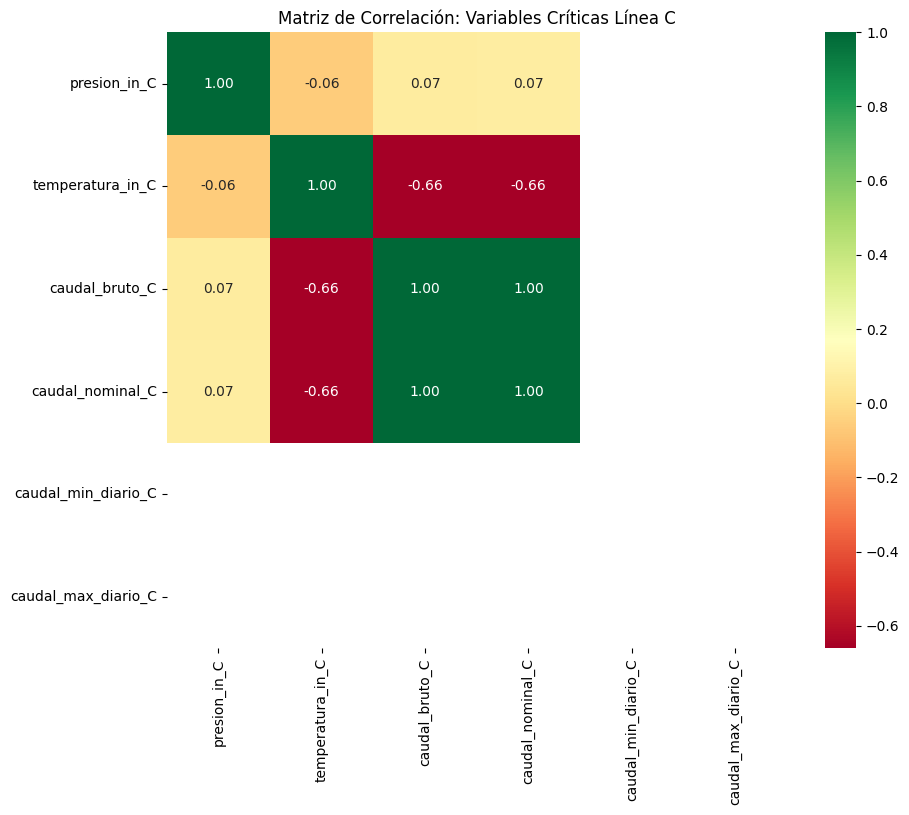

In [85]:
plt.figure(figsize=(10, 8))

"""
corr_matrix = df[['presion_in_A', 'presion_in_B', 'temperatura_in_A', 'temperatura_in_B',
       'caudal_bruto_A', 'caudal_bruto_B', 'caudal_nominal_A',
       'caudal_nominal_B', 'caudal_min_diario_A', 'caudal_min_diario_B',
       'caudal_max_diario_A', 'caudal_max_diario_B']].corr()
"""

corr_matrix = df[['presion_in_C', 'temperatura_in_C', 'caudal_bruto_C', 
                  'caudal_nominal_C', 'caudal_min_diario_C', 
                 'caudal_max_diario_C']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Matriz de Correlación: Variables Críticas Línea C')
plt.show()

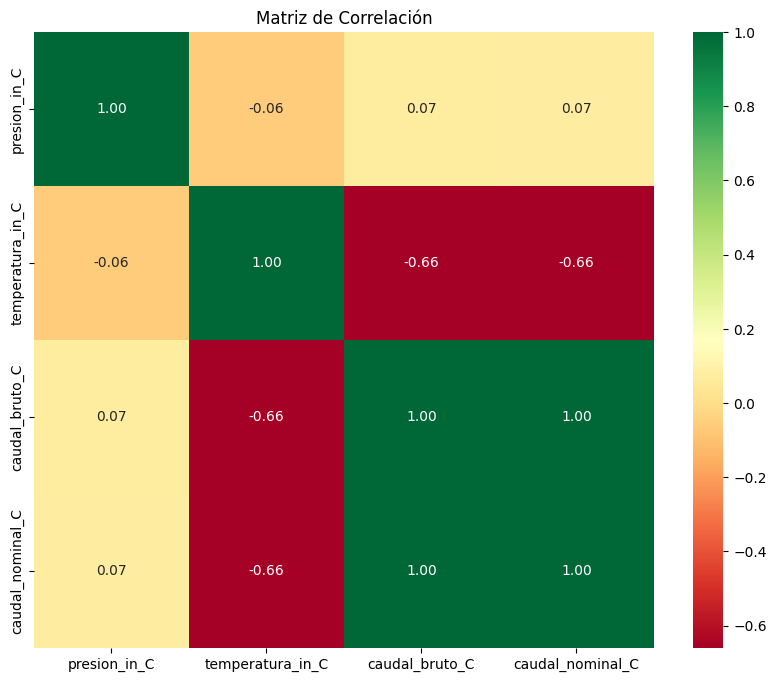

In [86]:
plt.figure(figsize=(10, 8))

"""
corr_matrix = df[['presion_in_A', 'temperatura_in_A',
       'caudal_bruto_A', 'caudal_nominal_A']].corr()
"""

corr_matrix = df[['presion_in_C', 'temperatura_in_C', 'caudal_bruto_C', 
                  'caudal_nominal_C']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

In [87]:
# Procesamiento de tiempo o fecha del fallo
df_sap[['Inicio avería','Ini.avería (h)','Inicio deseado','datetime_fallo']]

,Inicio avería,Ini.avería (h),Inicio deseado,datetime_fallo
0,NaN,00:00:00,2021-08-23,2021-08-23 00:00:00
1,NaN,00:00:00,2023-03-30,2023-03-30 00:00:00
2,NaN,00:00:00,2022-11-25,2022-11-25 00:00:00
3,NaN,00:00:00,2022-06-20,2022-06-20 00:00:00
4,NaN,00:00:00,2022-04-27,2022-04-27 00:00:00
5,NaN,00:00:00,2023-06-30,2023-06-30 00:00:00
6,NaN,00:00:00,2022-06-20,2022-06-20 00:00:00
7,NaN,00:00:00,2022-04-27,2022-04-27 00:00:00
8,NaN,00:00:00,2023-11-23,2023-11-23 00:00:00
9,NaN,00:00:00,2022-06-20,2022-06-20 00:00:00


## 1. Etiquetado del ANOMALIA USANDO AVISOS SAP

In [93]:
# Cruce de control: ¿Qué avisos SAP tienen datos en mi SCADA?
print(f"Rango SCADA: {df.index.min()} hasta {df.index.max()}")

trazabilidad = []

for i, fecha_f in enumerate(df_sap['datetime_fallo']):
    inicio_ventana = fecha_f - pd.Timedelta(days=7)
    # Verificamos si hay datos en esa ventana de 7 días
    datos_disponibles = df.loc[inicio_ventana:fecha_f]
    
    status = "DISPONIBLE" if not datos_disponibles.empty else "SIN DATOS SCADA"
    trazabilidad.append({
        'Indice': i,
        'Fecha Fallo': fecha_f,
        'Descripción': df_sap.iloc[i]['DESCRIPCIÓN AVISO'][:30],
        'Estado': status,
        'Registros encontrados': len(datos_disponibles)
    })

df_trazabilidad = pd.DataFrame(trazabilidad)
print("\n--- INFORME DE DISPONIBILIDAD DE FALLOS ---")
print(df_trazabilidad)

Rango SCADA: 2022-01-01 00:00:00 hasta 2023-01-01 00:00:00

--- INFORME DE DISPONIBILIDAD DE FALLOS ---
    Indice         Fecha Fallo                     Descripción  \
0        0 2021-08-23 00:00:00   Regulación. Disparo VIS LA/LB   
1        1 2023-03-30 00:00:00          Alarma Vis B- ERM_6500   
2        2 2022-11-25 00:00:00              Regulación viernes   
3        3 2022-06-20 00:00:00  ERM_6500 Fallo funcional Aperf   
4        4 2022-04-27 00:00:00  ERM_6500 Fallo regulacion Aper   
5        5 2023-06-30 00:00:00  29/6/23 Subir presion en ERM E   
6        6 2022-06-20 00:00:00  ERM_6500 Fallo funcional pilot   
7        7 2022-04-27 00:00:00   ERM_6500 sust piloto reg.ppal   
8        8 2023-11-23 00:00:00     22/11/23 2da.Linea ERM_6500   
9        9 2022-06-20 00:00:00  ERM_6500 Fallo funcional pilot   
10      10 2022-04-27 00:00:00  ERM_6500 Fallo funcional pilot   
11      11 2022-04-21 00:00:00  ERM_6500 Fallo Funcional pilot   
12      12 2023-04-11 00:00:00  29/03/

1.1 Definicion de Punto de Corte para Avisos SAP

ERM 400: Aviso SAP del 2023-01-30 00:00:00 (Línea A).

ERM 6500: Aviso SAP del 2022-11-25 00:00:00 (Línea C).

ERM 400

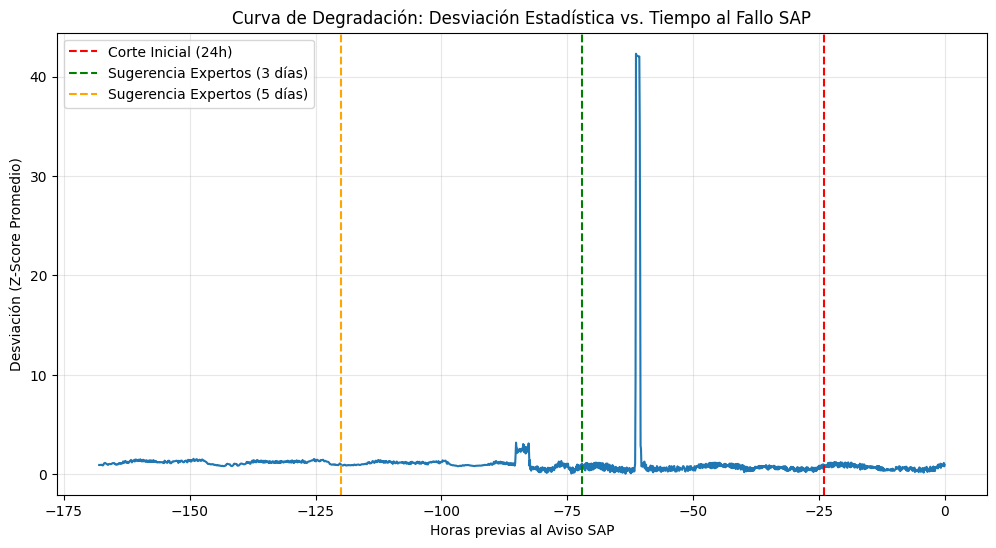

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Selección de variables dinámicas (omitimos las de varianza cero como caudal_min)
variables_analisis = ['presion_in_A', 'temperatura_in_A', 
                       'caudal_nominal_A']

# 2. Definición de la Población de Control (Operación Normal)
# Filtramos periodos que sabemos están lejos de cualquier fallo (ej. más de 10 días de distancia)
df_control = df.copy()
for fecha in df_sap['datetime_fallo']:
    mask_cerca_fallo = (df_control.index >= fecha - pd.Timedelta(days=10)) & \
                       (df_control.index <= fecha + pd.Timedelta(days=1))
    df_control = df_control[~df_control.index.isin(df_control[mask_cerca_fallo].index)]

# Calculamos media y desviación estándar de la normalidad
stats_normal = df_control[variables_analisis].agg(['mean', 'std']).T

# 3. Análisis de Ventanas Pre-Fallo (7 días atrás)
analisis_lote = []

for fecha_f in df_sap['datetime_fallo']:
    # Extraemos 7 días antes del aviso SAP
    inicio_ventana = fecha_f - pd.Timedelta(days=7)
    ventana_pre = df.loc[inicio_ventana:fecha_f, variables_analisis].copy()
    
    if ventana_pre.empty:
        continue

    # Calculamos el Z-Score para cada variable (Distancia estadística a la normalidad)
    for var in variables_analisis:
        ventana_pre[f'z_{var}'] = (ventana_pre[var] - stats_normal.loc[var, 'mean']) / stats_normal.loc[var, 'std']
    
    # Calculamos la Desviación Promedio Absoluta de todas las variables
    z_cols = [f'z_{v}' for v in variables_analisis]
    ventana_pre['desviacion_total'] = ventana_pre[z_cols].abs().mean(axis=1)
    
    # Tiempo relativo al fallo en horas (0 es el momento del aviso SAP)
    ventana_pre['horas_respecto_fallo'] = (ventana_pre.index - fecha_f).total_seconds() / 3600
    analisis_lote.append(ventana_pre[['horas_respecto_fallo', 'desviacion_total']])

# 4. Consolidación de resultados
df_curva_degradacion = pd.concat(analisis_lote)

# 5. Visualización de la Curva de Persistencia
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_curva_degradacion, x='horas_respecto_fallo', y='desviacion_total', errorbar=('ci', 95))

# Marcas de referencia para la justificación
plt.axvline(x=-24, color='red', linestyle='--', label='Corte Inicial (24h)')
plt.axvline(x=-72, color='green', linestyle='--', label='Sugerencia Expertos (3 días)')
plt.axvline(x=-120, color='orange', linestyle='--', label='Sugerencia Expertos (5 días)')

plt.title("Curva de Degradación: Desviación Estadística vs. Tiempo al Fallo SAP")
plt.xlabel("Horas previas al Aviso SAP")
plt.ylabel("Desviación (Z-Score Promedio)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

ERM 6500

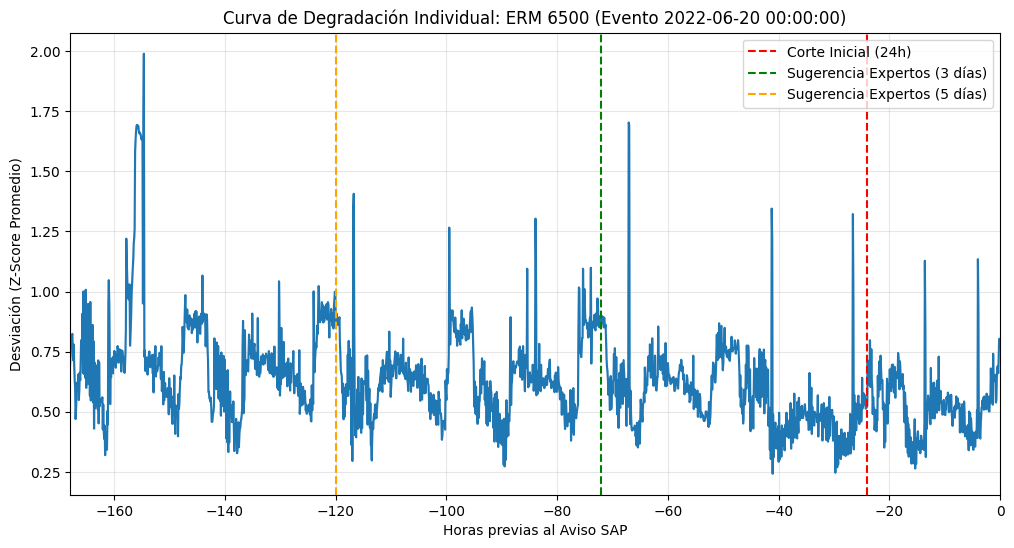

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# CONFIGURACIÓN PARA ERM 6500 - FECHA ESPECÍFICA
# ==========================================
# 1. Ajustamos las variables a la Línea C
variables_analisis = ['presion_in_C', 'temperatura_in_C', 'caudal_nominal_C']

# 2. Filtramos el df_sap para analizar SOLO la fecha de interés
fecha_interes = '2022-06-20 00:00:00'
df_sap_filtrado = df_sap[df_sap['datetime_fallo'] == fecha_interes].copy()

# ==========================================
# EL CÓDIGO TAL CUAL LO USAS (ESTRUCTURA ERM 400)
# ==========================================

# 2. Definición de la Población de Control (Operación Normal)
df_control = df.copy()
for fecha in df_sap['datetime_fallo']:
    mask_cerca_fallo = (df_control.index >= fecha - pd.Timedelta(days=10)) & \
                       (df_control.index <= fecha + pd.Timedelta(days=1))
    df_control = df_control[~df_control.index.isin(df_control[mask_cerca_fallo].index)]

# Calculamos media y desviación estándar de la normalidad
stats_normal = df_control[variables_analisis].agg(['mean', 'std']).T

# 3. Análisis de Ventanas Pre-Fallo (7 días atrás)
analisis_lote = []

# Usamos el dataframe filtrado para que solo procese la fecha del 20 de junio
for fecha_f in df_sap_filtrado['datetime_fallo']:
    # Extraemos 7 días antes del aviso SAP
    inicio_ventana = fecha_f - pd.Timedelta(days=7)
    ventana_pre = df.loc[inicio_ventana:fecha_f, variables_analisis].copy()
    
    if ventana_pre.empty:
        print(f"⚠️ No hay datos en SCADA para la ventana previa a {fecha_f}")
        continue

    # Calculamos el Z-Score para cada variable
    for var in variables_analisis:
        ventana_pre[f'z_{var}'] = (ventana_pre[var] - stats_normal.loc[var, 'mean']) / stats_normal.loc[var, 'std']
    
    # Calculamos la Desviación Promedio Absoluta
    z_cols = [f'z_{v}' for v in variables_analisis]
    ventana_pre['desviacion_total'] = ventana_pre[z_cols].abs().mean(axis=1)
    
    # Tiempo relativo al fallo en horas
    ventana_pre['horas_respecto_fallo'] = (ventana_pre.index - fecha_f).total_seconds() / 3600
    analisis_lote.append(ventana_pre[['horas_respecto_fallo', 'desviacion_total']])

# 4. Consolidación de resultados
if analisis_lote:
    df_curva_degradacion = pd.concat(analisis_lote)

    # 5. Visualización de la Curva de Persistencia (Igual que ERM 400)
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_curva_degradacion, x='horas_respecto_fallo', y='desviacion_total', errorbar=('ci', 95))

    # Marcas de referencia para la justificación
    plt.axvline(x=-24, color='red', linestyle='--', label='Corte Inicial (24h)')
    plt.axvline(x=-72, color='green', linestyle='--', label='Sugerencia Expertos (3 días)')
    plt.axvline(x=-120, color='orange', linestyle='--', label='Sugerencia Expertos (5 días)')

    plt.title(f"Curva de Degradación Individual: ERM 6500 (Evento {fecha_interes})")
    plt.xlabel("Horas previas al Aviso SAP")
    plt.ylabel("Desviación (Z-Score Promedio)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Forzamos que el eje X muestre hasta los 7 días (-168 horas)
    plt.xlim(-168, 0) 
    
    plt.show()
else:
    print("No se pudo generar el gráfico por falta de datos en la ventana seleccionada.")

In [56]:
# Inicializamos todo en 0
df['is_anomaly_sap'] = 0

for fecha_exacta in df_sap['datetime_fallo']:
    # Definimos el rango: desde 72h antes hasta el momento del fallo
    inicio_ventana = fecha_exacta - pd.Timedelta(hours=72) # 3dias
    fin_ventana = fecha_exacta
    
    # Aplicamos la máscara con AMBOS límites
    mask = (df.index >= inicio_ventana) & (df.index <= fin_ventana)
    
    # Solo las filas en este rango pasan a ser 1
    df.loc[mask, 'is_anomaly_sap'] = 1

print(f"Registros etiquetados como anomalía (72h sintoma-fallo): {df['is_anomaly_sap'].sum()}")

Registros etiquetados como anomalía (72h sintoma-fallo): 865


In [57]:
df.head(2)

,presion_in_A,presion_in_B,temperatura_in_A,temperatura_in_B,caudal_bruto_A,caudal_bruto_B,caudal_nominal_A,caudal_nominal_B,caudal_min_diario_A,caudal_min_diario_B,caudal_max_diario_A,caudal_max_diario_B,is_anomaly_sap
datetime,,,,,,,,,,,,,
2023-01-01 00:00:00,16.784145,16.792011,11.613059,4.581303,0.0,49.199109,0.0,841.179544,0,0,64135.745844,13746.320905,0
2023-01-01 00:05:00,16.760601,16.767427,11.588407,13.210862,0.0,41.060760,0.0,677.303323,0,0,64135.745844,13746.320905,0


In [58]:
# 1. Inicializamos la columna
df['tipo_fallo_sap_detalle'] = "Normal"

# 2. Solo para las filas donde is_anomaly es 1, buscamos su descripción en df_sap
for _, row_sap in df_sap.iterrows():
    # 3.Buscamos en el df principal las filas que coincidan con el periodo de este aviso
    fecha_f = row_sap['datetime_fallo']
    
    # 4.IMPORTANTE: Definir la ventana de 72h específica para este aviso
    inicio_ventana = fecha_f - pd.Timedelta(hours=72)
    fin_ventana = fecha_f

    # 5.Extraemos la descripción
    desc = str(row_sap['DESCRIPCIÓN AVISO'])
    
    # 6.Marcamos el detalle solo donde is_anomaly ya es 1 
    # y la fecha coincide con este aviso específico
    mask_este_aviso = (df.index >= inicio_ventana) & (df.index <= fin_ventana)
    
    # 7. Asignamos la descripción detallada
    df.loc[mask_este_aviso, 'tipo_fallo_sap_detalle'] = f"SAP: {desc}"

# Verificamos qué nombres de fallos han quedado
print(df[df['is_anomaly_sap'] == 1]['tipo_fallo_sap_detalle'].value_counts())

tipo_fallo_sap_detalle
SAP: 27/01/23 Limpieza Pilotos ERM_400    865
Name: count, dtype: int64


In [59]:
df["is_anomaly_sap"].value_counts()

is_anomaly_sap
0    104244
1       865
Name: count, dtype: int64

### Validación de "Ceros" en la Ventana de 74horas

### Auditoría de Ceros en Ventana de Anomalía
Vamos a calcular exactamente qué porcentaje de ceros hay en cada variable crítica solo dentro de las filas que has marcado como anomalía. Esto confirmará si el fallo detectado por SAP tiene señal física que el modelo pueda aprender.

In [60]:
# Variables críticas de la Línea A
variables_analisis = ['presion_in_A', 'temperatura_in_A', 'caudal_bruto_A', 'caudal_nominal_A', 'caudal_min_diario_A', 'caudal_max_diario_A']

#variables_analisis = ['presion_in_C', 'temperatura_in_C', 'caudal_bruto_C', 'caudal_nominal_C', 'caudal_min_diario_C', 'caudal_max_diario_C']

print("--- Auditoría de Pureza en Ventana de Anomalía (SAP) ---")
df_anomalos = df[df['is_anomaly_sap'] == 1]

for var in variables_analisis:
    total_obs = len(df_anomalos)
    ceros = (df_anomalos[var] == 0).sum()
    pct_ceros = (ceros / total_obs) * 100
    print(f"Variable {var:.<20} | Ceros: {ceros} ({pct_ceros:.2f}%)")

--- Auditoría de Pureza en Ventana de Anomalía (SAP) ---
Variable presion_in_A........ | Ceros: 0 (0.00%)
Variable temperatura_in_A.... | Ceros: 0 (0.00%)
Variable caudal_bruto_A...... | Ceros: 11 (1.27%)
Variable caudal_nominal_A.... | Ceros: 11 (1.27%)
Variable caudal_min_diario_A. | Ceros: 865 (100.00%)
Variable caudal_max_diario_A. | Ceros: 0 (0.00%)


## 2. Isolation Forest para detectar "Anomalias" Y Ver cuantos concuerdan con los fallos reales de SAP AVISOS

In [ ]:
df["is_anomaly"].value_counts()

is_anomaly
0    104818
1       291
Name: count, dtype: int64

In [ ]:
from sklearn.ensemble import IsolationForest

# Seleccionamos variables clave según el Word (Presión + Caudal)
features = ['presion_in_A', 'temperatura_in_A',
            'caudal_nominal_A', 'caudal_bruto_A','caudal_max_diario_A']

# Ajustamos el Isolation Forest con la visión completa de la ERM
#n_estimators=100: Crea 100 árboles de decisión aleatorios.
#contamination=0.02: Tú le estás diciendo: "Sé que aproximadamente el 2% de mis datos son raros o fallos". El algoritmo ajusta el umbral para marcar ese 2% más raro.
#random_state=42: Para que siempre que corras el código obtengas las mismas anomalías.
# tamaño de la muestra (max_samples)
clf = IsolationForest(contamination=0.02, max_samples=256,random_state=42) 
df['anomaly_IF'] = clf.fit_predict(df[features])

# Convertir: -1 es anomalía en IF, lo pasamos a 1
df['anomaly_IF'] = df['anomaly_IF'].map({1: 0, -1: 1})

# 3. Cálculo de Concordancia (Matriz de Confusión)
# Comparamos is_anomaly (SAP) contra anomaly_IF (Modelo)
concordancia = df[(df['is_anomaly'] == 1) & (df['anomaly_IF'] == 1)].shape[0]
total_sap = df['is_anomaly'].sum()
porcentaje_exito = (concordancia / total_sap) * 100

print(f"--- RESULTADOS DE VALIDACIÓN ---")
print(f"Total registros SAP (Anomalías Reales): {total_sap}")
print(f"Anomalías SAP detectadas por el IF: {concordancia}")
print(f"Precisión de detección (Recall): {porcentaje_exito:.2f}%")

# 4. Target Final Consolidado
df['target_final'] = ((df['is_anomaly'] == 1) | (df['anomaly_IF'] == 1)).astype(int)

--- RESULTADOS DE VALIDACIÓN ---
Total registros SAP (Anomalías Reales): 291
Anomalías SAP detectadas por el IF: 0
Precisión de detección (Recall): 0.00%


In [ ]:
df["anomaly_IF"].value_counts()

anomaly_IF
0    103006
1      2103
Name: count, dtype: int64

In [ ]:
pd.options.display.max_columns = None
pd.options.display.max_rows = None
base_path = r"C:\Users\braya\Documents\TFM_UCM_Enagas\tfm_enagas"
processed_path = os.path.join(base_path, "data", "processed")

df_1s_if=df[df["anomaly_IF"]==1]
df_1s_if.to_csv(os.path.join(processed_path, "df_sap_erm_400_limpio_IF_target_1s.csv"), index=False)

## 1. Análisis Técnico: Mapeo de Anomalías IF a Modos de Fallo SCADA
Podemos automatizar esta columna "Fallo_SCADA" con el siguiente análisis sobre los registros anómalos:

In [ ]:
df_1s_if.head(3)

,presion_in_A,presion_in_B,temperatura_in_A,temperatura_in_B,caudal_bruto_A,caudal_bruto_B,caudal_nominal_A,caudal_nominal_B,caudal_min_diario_A,caudal_min_diario_B,caudal_max_diario_A,caudal_max_diario_B,turno,delta_presion_temp,is_anomaly,tipo_fallo_detalle,anomaly_IF,target_final
datetime,,,,,,,,,,,,,,,,,,
2023-01-02 18:20:00,16.579483,16.589111,12.620158,9.607299,0.0,119.075600,0.0,1964.091664,0,0,64135.745844,13746.320905,Tarde,0.004055,0,Normal,1,1
2023-01-02 18:25:00,16.581680,16.590967,12.626925,10.117414,0.0,119.145738,0.0,1961.401322,0,0,64135.745844,13746.320905,Tarde,0.002197,0,Normal,1,1
2023-01-02 18:30:00,16.566820,16.576109,12.630707,10.631184,0.0,121.573264,0.0,1995.285601,0,0,64135.745844,13746.320905,Tarde,0.014860,0,Normal,1,1


## Veamos si las anomalías detectadas por el IF, corresponde a algunas reglas de WORD SCADA

In [ ]:
import pandas as pd
import numpy as np

# Cargamos los datos donde el IF detectó algo
df_if = pd.read_csv(r'C:\Users\braya\Documents\TFM_UCM_Enagas\tfm_enagas\data\processed\df_sap_erm_400_limpio_IF_target_1s.csv')

def clasificar_fallo_scada(row):
    if row['anomaly_IF'] == 0:
        return "Normal"
    
    # Lógica 1: Caudal 0 con presión inestable (Pérdida de estanqueidad)
    if row['caudal_bruto_A'] <= 0.1 and row['delta_presion_temp'] > 0.01:
        return "Pastilla desgastada (Falta Estanqueidad)"
    
    # Lógica 2: Fluctuaciones (Basado en Delta Presion alto con caudal alto)
    if row['delta_presion_temp'] > 0.05:
        return "Membrana deformada / Anillos guía sucios"
    
    # Lógica 3: Inestabilidad de flujo
    if row['caudal_nominal_A'] > 0 and row['caudal_bruto_A'] < 10:
        return "Obturador sucio / Filtro colmatado"
    
    return "Anomalía Estadística no clasificada"

# Creamos la nueva columna
df_if['fallo_especifico_scada'] = df_if.apply(clasificar_fallo_scada, axis=1)

# Ver resultados de la clasificación
print(df_if[df_if['anomaly_IF']==1]['fallo_especifico_scada'].value_counts())

fallo_especifico_scada
Anomalía Estadística no clasificada         1826
Membrana deformada / Anillos guía sucios     175
Pastilla desgastada (Falta Estanqueidad)      88
Obturador sucio / Filtro colmatado            14
Name: count, dtype: int64


## Etiquetacion con SCADA

### Propuesta de "Lógica Inversa": 
Etiquetado basado en Reglas de Experto
Tu idea de usar las 3 reglas del manual SCADA para crear etiquetas es excelente y es lo que en IA llamamos Sistemas Basados en Reglas (Rule-Based Systems) o Etiquetado Programático.

In [ ]:
df.head(2)

,presion_in_A,presion_in_B,temperatura_in_A,temperatura_in_B,caudal_bruto_A,caudal_bruto_B,caudal_nominal_A,caudal_nominal_B,caudal_min_diario_A,caudal_min_diario_B,caudal_max_diario_A,caudal_max_diario_B,turno,delta_presion_temp,is_anomaly,tipo_fallo_detalle,anomaly_IF,target_final
datetime,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,16.784145,16.792011,11.613059,4.581303,0.0,49.199109,0.0,841.179544,0,0,64135.745844,13746.320905,Noche,NaN,0,Normal,0,0
2023-01-01 00:05:00,16.760601,16.767427,11.588407,13.210862,0.0,41.060760,0.0,677.303323,0,0,64135.745844,13746.320905,Noche,0.023544,0,Normal,0,0


In [12]:
# Cálculo correcto: Diferencia temporal en la misma línea (Línea C)
# Usamos .abs() porque el manual habla de "fluctuaciones" (subidas o bajadas bruscas)
df['delta_presion_temp'] = df['presion_in_A'].diff().abs()

In [13]:
# Aplicar reglas de experto SCADA a todo el dataset
df['is_scada_anomaly'] = 0
df['tipo_fallo_scada'] = 'Normal'

# Regla 1: Pastilla desgastada (Falta Estanqueidad)
mask_estanqueidad = (df['caudal_bruto_A'] <= 0.1) & (df['delta_presion_temp'] > 0.01)
df.loc[mask_estanqueidad, 'is_scada_anomaly'] = 1
df.loc[mask_estanqueidad, 'tipo_fallo_scada'] = 'Pastilla desgastada'

# Regla 2: Membrana deformada / Anillos guía sucios
# Añadimos: solo si no ha sido marcada por la Regla 1
mask_fluctuacion = (df['delta_presion_temp'] > 0.05) & (df['is_scada_anomaly'] == 0)
df.loc[mask_fluctuacion, 'is_scada_anomaly'] = 1
df.loc[mask_fluctuacion, 'tipo_fallo_scada'] = 'Membrana/Anillos sucios'

# Regla 3: Obturador sucio / Filtro colmatado
# Añadimos: solo si no ha sido marcada por la Regla 1 o 2
mask_obturador = (df['caudal_nominal_A'] > 0) & (df['caudal_bruto_A'] < 10) & (df['is_scada_anomaly'] == 0)
df.loc[mask_obturador, 'is_scada_anomaly'] = 1
df.loc[mask_obturador, 'tipo_fallo_scada'] = 'Obturador sucio/Filtro'

# Nuevo Target Consolidado: SAP + REGLAS EXPERTAS
df['target_final_v2'] = ((df['is_anomaly'] == 1) | (df['is_scada_anomaly'] == 1)).astype(int)

print(f"Anomalías por SAP: {df['is_anomaly'].sum()}")
print(f"Anomalías por Reglas SCADA: {df['is_scada_anomaly'].sum()}")
print(f"Total Anomalías para entrenar el modelo: {df['target_final_v2'].sum()}")

Anomalías por SAP: 291
Anomalías por Reglas SCADA: 8157
Total Anomalías para entrenar el modelo: 8448


In [14]:
df.head(2)

,presion_in_A,presion_in_B,temperatura_in_A,temperatura_in_B,caudal_bruto_A,caudal_bruto_B,caudal_nominal_A,caudal_nominal_B,caudal_min_diario_A,caudal_min_diario_B,caudal_max_diario_A,caudal_max_diario_B,is_anomaly,tipo_fallo_detalle,is_scada_anomaly,tipo_fallo_scada,delta_presion_temp,target_final_v2
datetime,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,16.784145,16.792011,11.613059,4.581303,0.0,49.199109,0.0,841.179544,0,0,64135.745844,13746.320905,0,Normal,0,Normal,NaN,0
2023-01-01 00:05:00,16.760601,16.767427,11.588407,13.210862,0.0,41.060760,0.0,677.303323,0,0,64135.745844,13746.320905,0,Normal,1,Pastilla desgastada,0.023544,1


In [15]:
# 1. Análisis de Concordancia (Intersección)
interseccion = df[(df['is_anomaly'] == 1) & (df['is_scada_anomaly'] == 1)].shape[0]
solo_sap = df[(df['is_anomaly'] == 1) & (df['is_scada_anomaly'] == 0)].shape[0]
solo_scada = df[(df['is_anomaly'] == 0) & (df['is_scada_anomaly'] == 1)].shape[0]

print("--- ANÁLISIS 1: CONCORDANCIA SAP VS SCADA ---")
print(f"Anomalías detectadas por AMBOS (Concordancia): {interseccion}")
print(f"Anomalías que SOLO SAP detectó: {solo_sap}")
print(f"Anomalías que SOLO las Reglas SCADA detectaron: {solo_scada}")
print("-" * 40)

# 2. Análisis de Clasificación de Fallos SCADA
# Vamos a ver qué reglas de SCADA están saltando más
estanqueidad = df[mask_estanqueidad].shape[0]
fluctuacion = df[mask_fluctuacion].shape[0]
obturador = df[mask_obturador].shape[0]

print("--- ANÁLISIS 2: DISTRIBUCIÓN DE FALLOS SCADA (ERM_400) ---")
print(f"Registros con 'Pastilla desgastada' (Caudal 0 + Salto P): {estanqueidad}")
print(f"Registros con 'Membrana/Anillos sucios' (Salto P brusco): {fluctuacion}")
print(f"Registros con 'Obturador sucio/Filtro' (Caudal nominal vs bruto): {obturador}")
print(f"SUMA TOTAL REGLAS: {estanqueidad + fluctuacion + obturador}")
print(f"TOTAL is_scada_anomaly: {df['is_scada_anomaly'].sum()}")

--- ANÁLISIS 1: CONCORDANCIA SAP VS SCADA ---
Anomalías detectadas por AMBOS (Concordancia): 0
Anomalías que SOLO SAP detectó: 291
Anomalías que SOLO las Reglas SCADA detectaron: 8157
----------------------------------------
--- ANÁLISIS 2: DISTRIBUCIÓN DE FALLOS SCADA (ERM_400) ---
Registros con 'Pastilla desgastada' (Caudal 0 + Salto P): 4370
Registros con 'Membrana/Anillos sucios' (Salto P brusco): 3756
Registros con 'Obturador sucio/Filtro' (Caudal nominal vs bruto): 31
SUMA TOTAL REGLAS: 8157
TOTAL is_scada_anomaly: 8157


In [16]:
# Variables a analizar de la Línea A
variables_A = ['presion_in_A', 'temperatura_in_A', 'caudal_bruto_A', 'caudal_nominal_A']

print("--- AUDITORÍA DE PUREZA: ETIQUETAS POR REGLAS SCADA ---")
# Filtramos solo las filas que marcaste con las reglas de SCADA
df_solo_scada = df[df['is_scada_anomaly'] == 1]

for var in variables_A:
    total_obs = len(df_solo_scada)
    ceros = (df_solo_scada[var] == 0).sum()
    pct_ceros = (ceros / total_obs) * 100
    print(f"Variable {var:.<25} | Ceros: {ceros} ({pct_ceros:.2f}%)")

--- AUDITORÍA DE PUREZA: ETIQUETAS POR REGLAS SCADA ---
Variable presion_in_A............. | Ceros: 0 (0.00%)
Variable temperatura_in_A......... | Ceros: 0 (0.00%)
Variable caudal_bruto_A........... | Ceros: 4369 (53.56%)
Variable caudal_nominal_A......... | Ceros: 4369 (53.56%)


In [17]:
df["is_scada_anomaly"].value_counts()

is_scada_anomaly
0    96952
1     8157
Name: count, dtype: int64

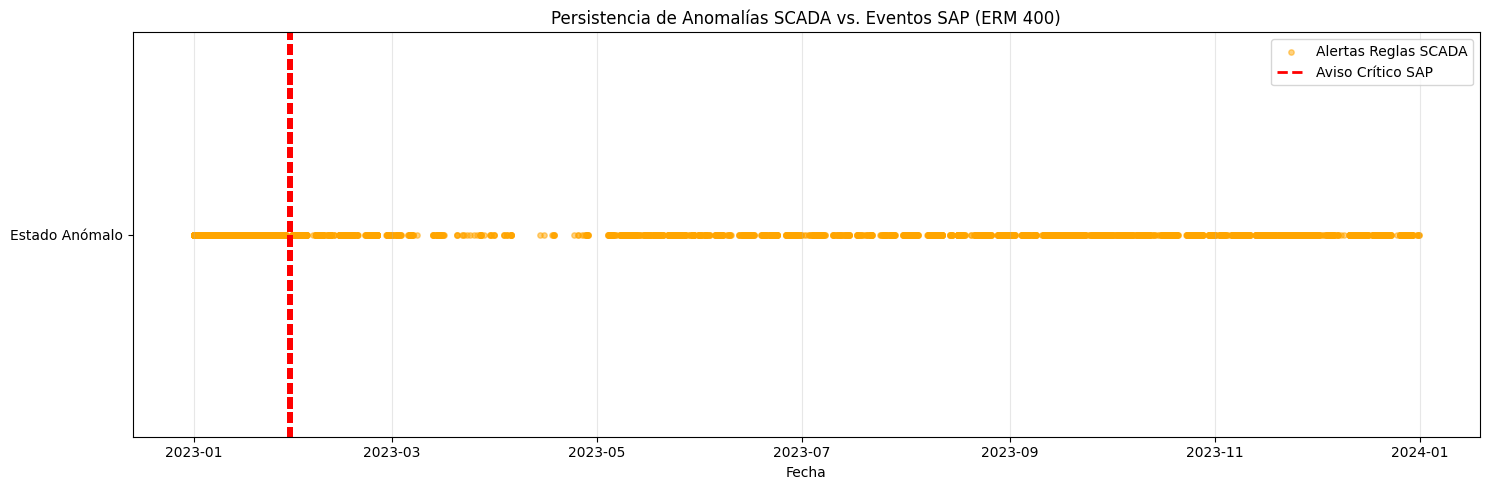

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# 1. Graficar Anomalías SCADA (Reglas)
anomalias_scada = df[df['is_scada_anomaly'] == 1]
plt.scatter(anomalias_scada.index, [1] * len(anomalias_scada), 
            alpha=0.5, s=15, color='orange', label='Alertas Reglas SCADA')

# 2. Graficar Avisos SAP (Sin duplicar leyenda)
avisos_sap = df[df['is_anomaly'] == 1]
for i, fecha in enumerate(avisos_sap.index):
    # Solo añadimos el label a la primera línea roja que encuentre
    label_sap = 'Aviso Crítico SAP' if i == 0 else ""
    plt.axvline(x=fecha, color='red', linestyle='--', linewidth=2, label=label_sap)

plt.title('Persistencia de Anomalías SCADA vs. Eventos SAP (ERM 400)')
plt.ylim(0.5, 1.5)
plt.yticks([1], ['Estado Anómalo'])
plt.xlabel('Fecha')
plt.legend(loc='upper right', frameon=True)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Opción 1: Subplots con Matplotlib

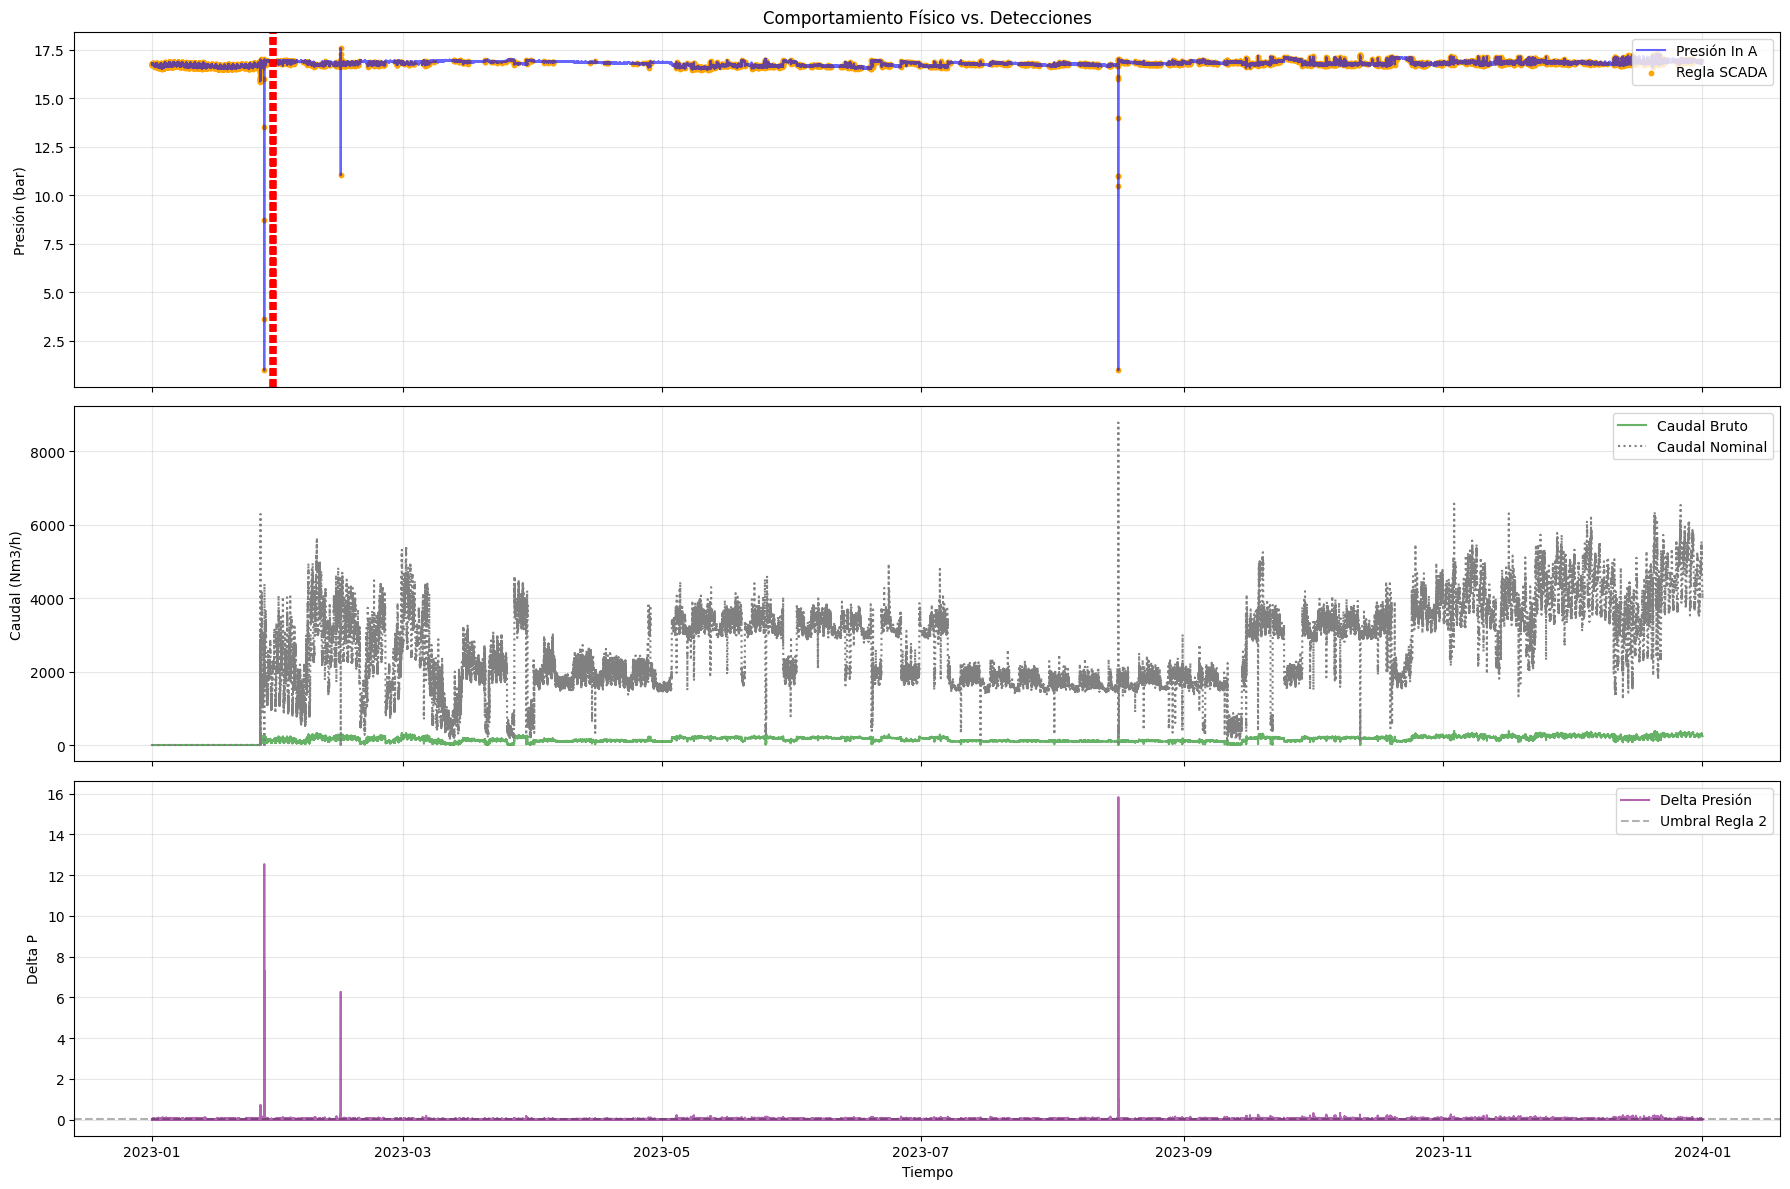

In [ ]:
import matplotlib.pyplot as plt

# Creamos 3 subplots que comparten el eje X (el tiempo)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# 1. Gráfico de Presión y Anomalías
ax1.plot(df.index, df['presion_in_A'], color='blue', alpha=0.6, label='Presión In A')
ax1.set_ylabel('Presión (bar)')
ax1.set_title('Comportamiento Físico vs. Detecciones')

# Dibujar avisos SAP y SCADA sobre la presión
for fecha in df[df['is_anomaly'] == 1].index:
    ax1.axvline(x=fecha, color='red', linestyle='--', alpha=0.7)
    
anom_scada = df[df['is_scada_anomaly'] == 1]
ax1.scatter(anom_scada.index, anom_scada['presion_in_A'], color='orange', s=10, label='Regla SCADA')

# 2. Gráfico de Caudal
ax2.plot(df.index, df['caudal_bruto_A'], color='green', alpha=0.6, label='Caudal Bruto')
ax2.plot(df.index, df['caudal_nominal_A'], color='gray', linestyle=':', label='Caudal Nominal')
ax2.set_ylabel('Caudal (Nm3/h)')

# 3. Gráfico de Delta Presión (donde saltan la mayoría de reglas)
ax3.plot(df.index, df['delta_presion_temp'], color='purple', alpha=0.6, label='Delta Presión')
ax3.axhline(y=0.05, color='black', linestyle='--', alpha=0.3, label='Umbral Regla 2')
ax3.set_ylabel('Delta P')
ax3.set_xlabel('Tiempo')

# Ajustes finales
for ax in [ax1, ax2, ax3]:
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Opción 2: Gráfico Interactivo con Plotly

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Crear subplots interactivos
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                    vertical_spacing=0.05,
                    subplot_titles=("Presión y Anomalías", "Caudal"))

# Añadir Presión
fig.add_trace(go.Scatter(x=df.index, y=df['presion_in_A'], name="Presión", line=dict(color='blue')), row=1, col=1)

# Añadir Anomalías SCADA (puntos)
anom_scada = df[df['is_scada_anomaly'] == 1]
fig.add_trace(go.Scatter(x=anom_scada.index, y=anom_scada['presion_in_A'], 
                         mode='markers', name='Fallo SCADA', 
                         marker=dict(color='orange', size=6)), row=1, col=1)

# Añadir Caudal
fig.add_trace(go.Scatter(x=df.index, y=df['caudal_bruto_A'], name="Caudal Bruto", line=dict(color='green')), row=2, col=1)

# Añadir líneas verticales para SAP
for fecha in df[df['is_anomaly'] == 1].index:
    fig.add_vline(x=fecha, line_width=2, line_dash="dash", line_color="red", row='all')

fig.update_layout(height=800, title_text="Análisis Detallado de Anomalías - Proyecto Neptuno", showlegend=True)
fig.show(renderer="browser")

### Guardar Datos Etiquetados para entrenemientos de Modelos ML

In [19]:
df.head()

,presion_in_A,presion_in_B,temperatura_in_A,temperatura_in_B,caudal_bruto_A,caudal_bruto_B,caudal_nominal_A,caudal_nominal_B,caudal_min_diario_A,caudal_min_diario_B,caudal_max_diario_A,caudal_max_diario_B,is_anomaly,tipo_fallo_detalle,is_scada_anomaly,tipo_fallo_scada,delta_presion_temp,target_final_v2
datetime,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,16.784145,16.792011,11.613059,4.581303,0.0,49.199109,0.0,841.179544,0,0,64135.745844,13746.320905,0,Normal,0,Normal,NaN,0
2023-01-01 00:05:00,16.760601,16.767427,11.588407,13.210862,0.0,41.060760,0.0,677.303323,0,0,64135.745844,13746.320905,0,Normal,1,Pastilla desgastada,0.023544,1
2023-01-01 00:10:00,16.730278,16.738071,11.562312,16.203283,0.0,42.931357,0.0,698.337504,0,0,64135.745844,13746.320905,0,Normal,1,Pastilla desgastada,0.030323,1
2023-01-01 00:15:00,16.720991,16.728420,11.533041,14.399950,0.0,49.035714,0.0,802.273913,0,0,64135.745844,13746.320905,0,Normal,0,Normal,0.009287,0
2023-01-01 00:20:00,16.740030,16.746996,11.522590,11.267754,0.0,52.958340,0.0,878.008174,0,0,64135.745844,13746.320905,0,Normal,1,Pastilla desgastada,0.019039,1


In [ ]:
### Guardar Datos Etiquetados para entrenemientos de Modelos ML


In [21]:
# Guardamos el CSV
df.to_csv(r'C:\Users\braya\Documents\TFM_UCM_Enagas\tfm_enagas\data\processed\df_modelado_sintomas.csv')
print("Archivo listo para el notebook de ML.")

Archivo listo para el notebook de ML.
